In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

In [34]:
df = pd.read_csv('Mall_Customers.csv')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [38]:
unique = df['Genre'].unique()
unique

array(['Male', 'Female'], dtype=object)

In [39]:
df['Genre']= df['Genre'].map({'Male':0, 'Female': 1})

In [40]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [41]:
df = df.set_index('CustomerID')

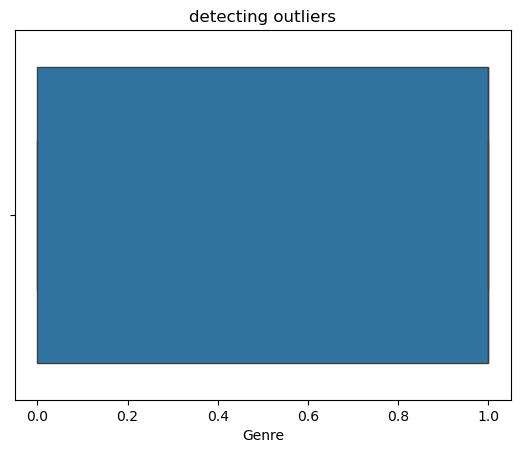

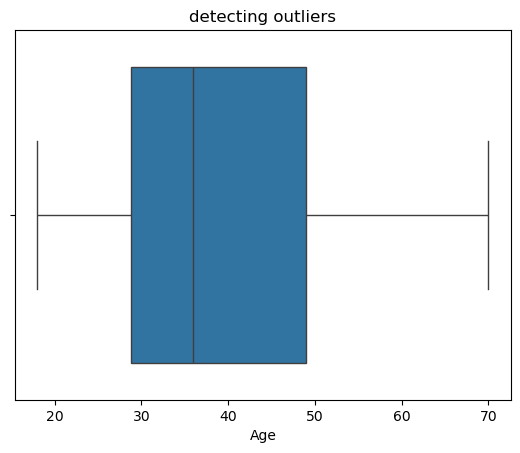

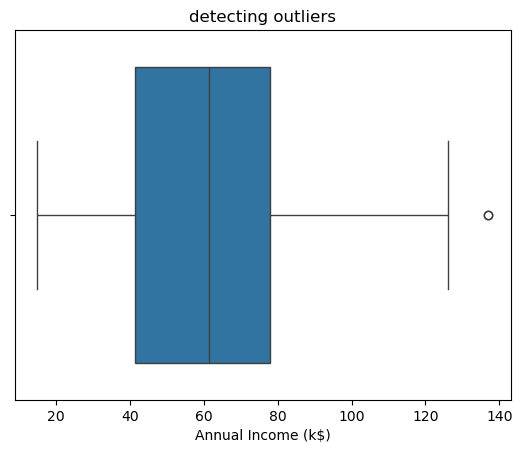

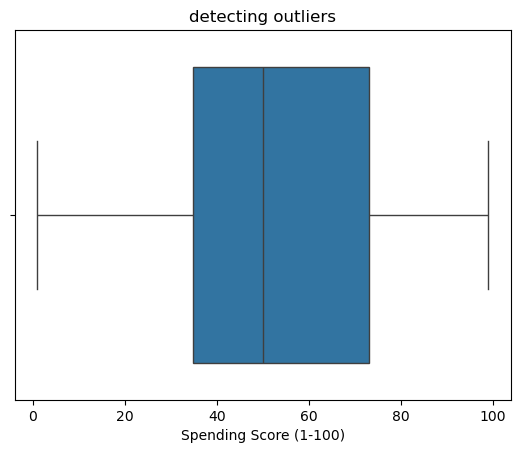

In [42]:
col = df[['Genre','Age','Annual Income (k$)','Spending Score (1-100)']]
for c in col:
    plt.Figure(figsize=(10,6))
    sns.boxplot(x=df[c])
    plt.title('detecting outliers')
    plt.show()

In [43]:
df['Annual Income (k$)'] = np.log1p(df['Annual Income (k$)'])

<Axes: >

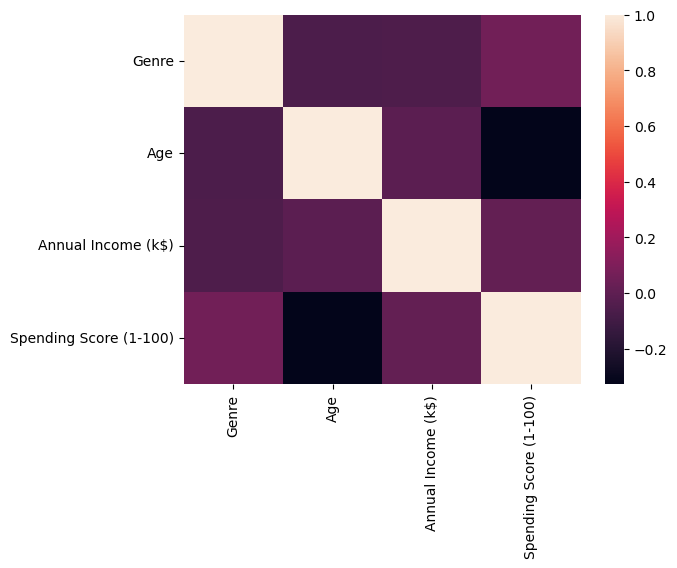

In [44]:
num_corr = col.corr()
sns.heatmap(num_corr)

In [45]:
mean = df['Annual Income (k$)'].mean()
std = df['Annual Income (k$)'].std()

In [46]:
df['z_score'] = (df['Annual Income (k$)']-mean)/std
df= df[df['Annual Income (k$)'].abs()<3].drop(columns=['z_score'])